# Visualisation of Results

Reproduces the figures in the paper and supplementary material.
Depends on the Algonauts 2025 challenge dataset and precomputed model outputs'.

To run the notebook:
1. Obtain the dataset from https://github.com/courtois-neuromod/algonauts_2025.competitors
3. Run training to generate model predictions
4. Update paths to datasets and results folder

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from statannotations.Annotator import Annotator
import numpy as np
import pandas as pd
import sys
import os
import warnings
warnings.filterwarnings("ignore")
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

from utils.visualise import  get_noise_ceiling, add_values_above_bars, add_signif_lines, plot_temporal_ablation, plot_time_series_comparison, get_encoder_comparison_figure
from evaluation.permutation_test_mutiple_comparisons import reduce_parcel_vector_to_areas
import pickle

# choose figure style
sns.set(style="whitegrid", context="paper", font_scale=1.3, font="arial")
# sns.set(style="whitegrid", context="talk", font_scale=1, font="arial")

subjects = [1,2,3,5]
palette =  sns.color_palette("Set3")[6:7] + sns.color_palette("Set3")[3:5] + sns.color_palette("Set3")[9:10]
palette2 =  sns.color_palette("Set3")[3:5]
palette_networks = sns.color_palette("Set3")[0:1] + sns.color_palette("Set3")[2:8]

# set path to Algonauts dataset
root_data_dir = "AFM/Algonauts_Data"
# set path to Results dataset
res_dir = "AFM/Results"

# Group vs Indiv


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

sub-01_group vs. sub-01_individual: Custom statistical test, P_val:5.000e-04
mean_group vs. mean_individual: Custom statistical test, P_val:5.000e-04
sub-02_group vs. sub-02_individual: Custom statistical test, P_val:5.000e-04
sub-03_group vs. sub-03_individual: Custom statistical test, P_val:5.000e-04
sub-05_group vs. sub-05_individual: Custom statistical test, P_val:5.000e-04


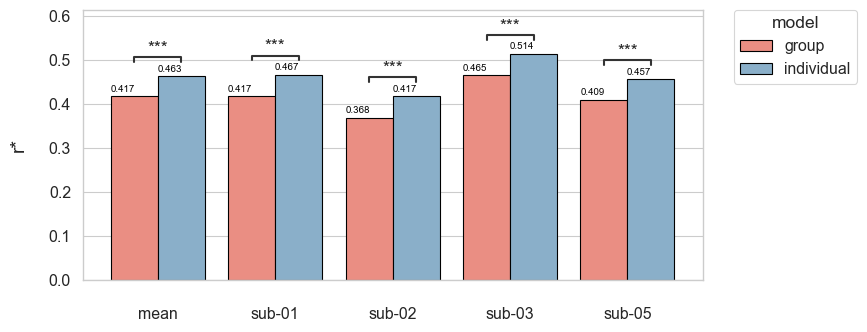

In [5]:
subjects = [1,2,3,5]
level = "per_subject"
noise_ceiling = get_noise_ceiling(root_data_dir, subjects, level, None)
level = "across_subjects"
noise_ceiling.insert(0,get_noise_ceiling(root_data_dir, subjects, level, None))

df_wide = pd.DataFrame({
    'Subject': ['mean', 'sub-01', 'sub-02', 'sub-03', 'sub-05'],
    
    'AFM_GRU_group': np.array([0.246, 0.246, 0.217, 0.274, 0.241]) / np.array(noise_ceiling[0]),
    'AFM_GRU_individual':  np.array([0.273, 0.275, 0.246, 0.303,0.269])/ np.array(noise_ceiling[0]),

})

df_long = df_wide.melt(id_vars='Subject', 
                       var_name='Framework_Model_Type', 
                       value_name='Correlation')

# split into separate "Framework" and "Model"
df_long[['Framework', 'Model', 'Type']] = df_long['Framework_Model_Type'].str.split('_', expand=True)

plt.figure(figsize=(8, 3.5))
ax = sns.barplot(
    data=df_long,
    x='Subject',
    y='Correlation',
    hue='Type',
    errorbar=None,        

    palette= palette2,
    edgecolor='black'
)

add_values_above_bars(ax, y_pos_adjust=0.01)
plt.ylabel("r*", labelpad=15, fontsize=14)
plt.xlabel("")
plt.legend(
    title='model',
    bbox_to_anchor=(1.05, 1), 
    loc='upper left',
    borderaxespad=0.
)

#significance bars
pairs = [
    (("mean", "group"), ("mean", "individual")),
    (("sub-01", "group"), ("sub-01", "individual")),
    (("sub-02", "group"), ("sub-02", "individual")),
    (("sub-03", "group"), ("sub-03", "individual")),
    (("sub-05", "group"), ("sub-05", "individual")),
]

p_vals_testset_default = [0.0001] * 5
reject, p_corr_testset_default, _, p_bon = multipletests(np.array(p_vals_testset_default), alpha=0.05, method="bonferroni")
annot = Annotator(ax, pairs, data=df_long, x="Subject", y="Correlation", hue="Type")
annot.configure(test=None, text_format="star", show_test_name=False, loc="inside")
annot.set_pvalues(p_corr_testset_default) 
annot.annotate()
plt.show()

# Encoder Comparison

In [6]:
def reduce_name(s):
    left, right = s.split("__vs__")
    left_fw = left.split("_")[0]
    right_fw = right.split("_")[0]
    if left_fw == right_fw:
        m1 = left.split("_")[1]
        m2 = right.split("_")[1]
        return "_".join([left_fw, m1, m2])


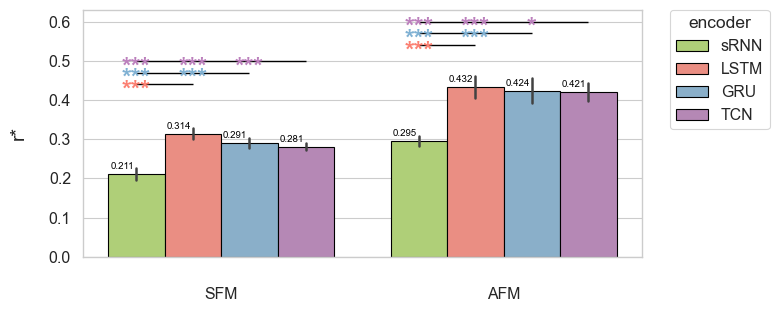

In [ ]:
df_wide_default_test = pd.DataFrame({
    'Subject': ['S1', 'S2', 'S3', 'S5'],
    
    'SFM_sRNN': [0.116, 0.129, 0.134, 0.116],
    'SFM_LSTM':   [0.180, 0.181, 0.201, 0.175],
    'SFM_GRU':    [0.167, 0.166, 0.187, 0.163],
    'SFM_TCN':    [0.164, 0.164, 0.174, 0.158],
    'AFM_sRNN': [0.174, 0.163, 0.190, 0.167],
    'AFM_LSTM':   [0.256, 0.230, 0.285, 0.247],
    'AFM_GRU':    [0.251, 0.223, 0.284, 0.241],
    'AFM_TCN':    [0.252, 0.225, 0.269, 0.244]
})

ax, df_hued = get_encoder_comparison_figure(root_data_dir, subjects, df_wide_default_test)

pairs = [
    (("SFM", "GRU"), ("SFM", "sRNN")),
    (("SFM", "TCN"), ("SFM", "sRNN")),
    (("SFM", "LSTM"), ("SFM", "TCN")),
    (("AFM", "GRU"), ("AFM", "sRNN")),
    (("AFM", "TCN"), ("AFM", "sRNN")),
    (("AFM", "LSTM"), ("AFM", "TCN")),
]

p_vals_testset_default = []
obs_testset_default = []
comparisons_results = np.load(fr"{res_dir}/perm_test_default_testset.npz").items()
sign_dict = {}

for key, value in comparisons_results:
   
    obs_testset_default.append(np.round(value[0],3))
    p_vals_testset_default.append(np.round(value[1], 4))

reject, p_corr_testset_default_sfm, _, p_bon = multipletests(p_vals_testset_default[:6], alpha=0.05, method="bonferroni")
reject, p_corr_testset_default_afm, _, p_bon = multipletests(p_vals_testset_default[6:], alpha=0.05, method="bonferroni")

i_s = 0
i_a=0
for (key, value) in comparisons_results:
    left, right = key.split("__vs__")
    left_fw = left.split("_")[0]
    right_fw = right.split("_")[0]
    if left_fw == right_fw == "sfm":
        sign_dict[reduce_name(key)] = p_corr_testset_default_sfm[i_s]
        i_s+=1
    elif left_fw == right_fw == "afm":
        sign_dict[reduce_name(key)]  = p_corr_testset_default_afm[i_a]
        i_a+=1

add_signif_lines(ax, 0.3, 0.5, sign_dict, "sfm")
add_signif_lines(ax, 1.3, 0.6, sign_dict, "afm")


plt.tight_layout()
plt.xlabel("")
plt.show()



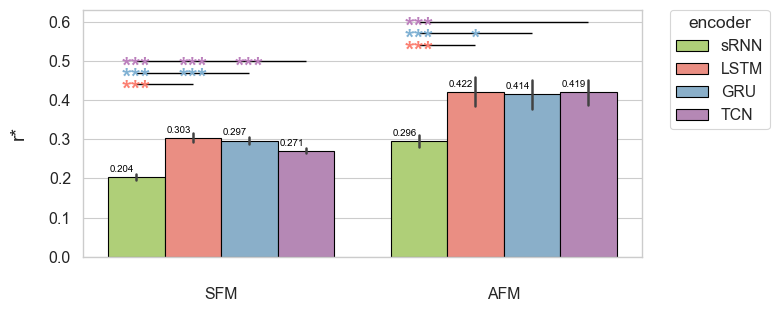

In [8]:
df_wide_default_hyper = pd.DataFrame({
    'Subject': ['S1', 'S2', 'S3', 'S5'],
    
    'SFM_sRNN': [0.124, 0.115, 0.132, 0.108],
    'SFM_LSTM':   [0.183, 0.167, 0.196, 0.168],
    'SFM_GRU':    [0.186, 0.163, 0.185, 0.164],
    'SFM_TCN':    [0.169, 0.150, 0.167, 0.152],
    'AFM_sRNN': [0.179, 0.159, 0.189, 0.169],
    'AFM_LSTM':   [0.253, 0.214, 0.276, 0.249],
    'AFM_GRU':    [0.248, 0.211, 0.273, 0.243],
    'AFM_TCN':    [0.255, 0.217, 0.266, 0.249]
})

sign_dict = {}

p_vals_sfm_hyper = [0.0001] * 6
p_vals_afm_hyper = [0.0034, 0.0001, 0.0238, 0.0001, 0.0001, 0.285]

ax, df_hued = get_encoder_comparison_figure(root_data_dir, subjects, df_wide_default_hyper)

pairs = [
    (("SFM", "GRU"), ("SFM", "sRNN")),
    (("SFM", "TCN"), ("SFM", "sRNN")),
    (("SFM", "LSTM"), ("SFM", "TCN")),
    (("AFM", "GRU"), ("AFM", "sRNN")),
    (("AFM", "TCN"), ("AFM", "sRNN")),
    (("AFM", "LSTM"), ("AFM", "TCN"))
]

sfm_keys = [
    'sfm_gru_lstm',
    'sfm_gru_simple',
    'sfm_gru_tcn',
    'sfm_lstm_tcn',
    'sfm_lstm_simple',
    'sfm_tcn_simple',
]

afm_keys = [
    'afm_gru_lstm',
    'afm_gru_simple',
    'afm_gru_tcn',
    'afm_lstm_simple',
    'afm_tcn_simple',
    'afm_lstm_tcn',
]

reject, p_corr_testset_default_sfm, _, p_bon = multipletests(p_vals_sfm_hyper, alpha=0.05, method="bonferroni")
reject, p_corr_testset_default_afm, _, p_bon = multipletests(p_vals_afm_hyper, alpha=0.05, method="bonferroni")

# update SFM entries
for key, p in zip(sfm_keys, p_corr_testset_default_sfm):
    sign_dict[key] = p

# update AFM entries
for key, p in zip(afm_keys, p_corr_testset_default_afm):
    sign_dict[key] = p

add_signif_lines(ax, 0.3, 0.5, sign_dict, "sfm")
add_signif_lines(ax, 1.3, 0.6, sign_dict, "afm")

plt.tight_layout()
plt.xlabel("")
plt.show()

# Hyperparameter comparison

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AFM_default vs. AFM_optimized: Custom statistical test, P_val:1.000e-04
SFM_default vs. SFM_optimized: Custom statistical test, P_val:1.000e-04


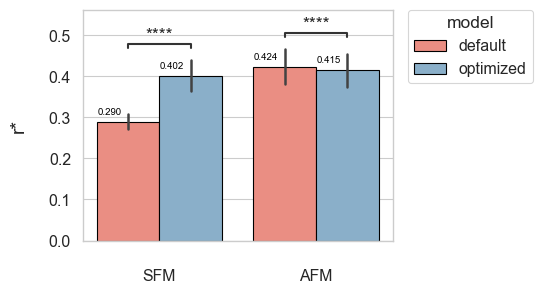

In [9]:
level = "per_subject"
noise_ceiling = get_noise_ceiling(root_data_dir, subjects, level, None)
level = "across_subjects"
noise_ceiling.insert(0,get_noise_ceiling(root_data_dir, subjects, level, None))

df_wide = pd.DataFrame({
    'Subject': ['sub-01', 'sub-02', 'sub-03', 'sub-05'],
    'SFM_default':    [0.167, 0.166, 0.187, 0.163]/ np.array(noise_ceiling[0]),
    'AFM_default':    [0.251, 0.223, 0.284, 0.241]/ np.array(noise_ceiling[0]),
    'SFM_optimized': np.array([0.236, 0.219, 0.269, 0.223]) / np.array(noise_ceiling[0]),
    'AFM_optimized':   np.array([0.246, 0.217, 0.274, 0.241]) / np.array(noise_ceiling[0]),
})

df_long = df_wide.melt(id_vars='Subject', 
                       var_name='Framework_Type', 
                       value_name='Correlation')

df_long[['Framework', 'Type']] = df_long['Framework_Type'].str.split('_', expand=True)

plt.figure(figsize=(4, 3))
ax = sns.barplot(
    data=df_long,
    x='Framework',
    y='Correlation',
    hue='Type',
    errorbar="sd",        
    palette=palette2,
    edgecolor='black'
)

add_values_above_bars(ax, x_pos_adjust=0.12)

plt.ylabel("r*",  labelpad=15, fontsize = 14)
plt.xlabel("")

plt.legend(
    title='model',
    bbox_to_anchor=(1.05, 1),  
    loc='upper left',
    borderaxespad=0.
)

# significance bars
pairs = [
    (("SFM", "default"), ("SFM", "optimized")),
    (("AFM", "default"), ("AFM", "optimized"))
]

p_vals_testset_default = [0.0001] * 2
annot = Annotator(ax, pairs, data=df_long, x="Framework", y="Correlation", hue="Type")
annot.configure(test=None, text_format="star", show_test_name=False, loc="inside")
annot.set_pvalues(p_vals_testset_default) 
annot.annotate()

plt.show()

# Ablation

In [10]:
res_dir = r"/Users/nicolerogalla/Documents/AFM/Flow-Matching-for-Probabilistic-Forecasting-of-fMRI-Time-Series/Results"
network_names = ["V", "SM", "DA", "VA", "L", "FP", "D"]
# for creation of area ids, run commented lines
# from utils.visualise import load_schaefer7_area_ids_from_lut
# # downloaded from https://github.com/ThomasYeoLab/CBIG/blob/master/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/fsleyes_lut/Schaefer2018_1000Parcels_17Networks_order.lut
# lut_path = fr"{res_dir}/Schaefer2018_1000Parcels_7Networks_order.lut" 
# area_ids = load_schaefer7_area_ids_from_lut(lut_path, expected_parcels=1000) 
# np.save(f"{res_dir}\area_ids", area_ids)
area_ids = np.load(fr"{res_dir}/area_ids.npy")


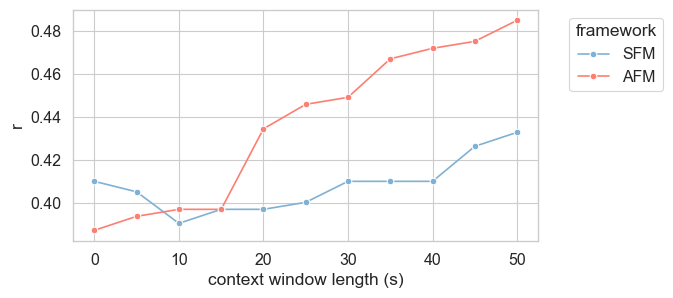

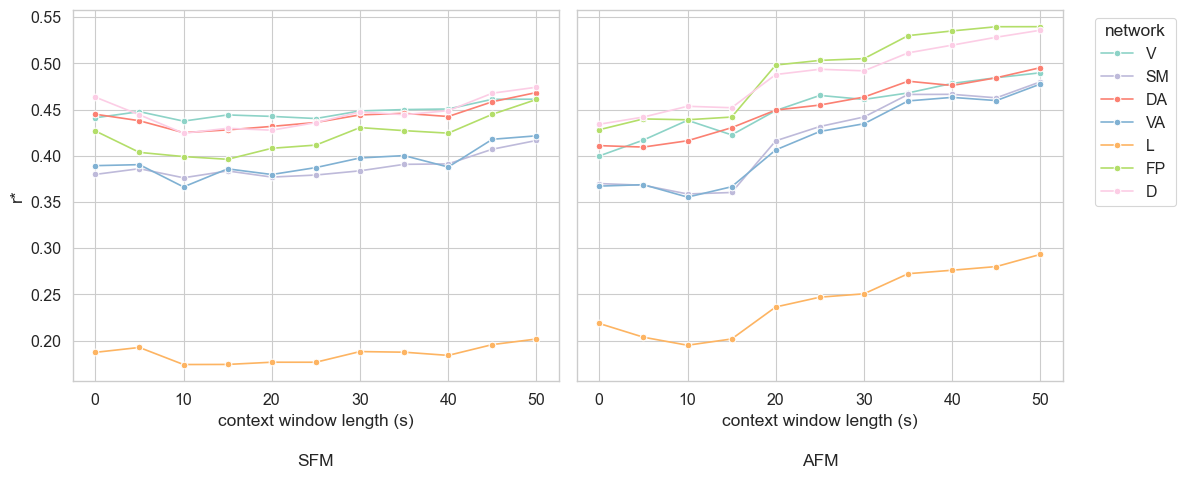

In [13]:
plot_temporal_ablation(root_data_dir, subjects, network_names, area_ids,palette_networks,  ablation_type = "context")

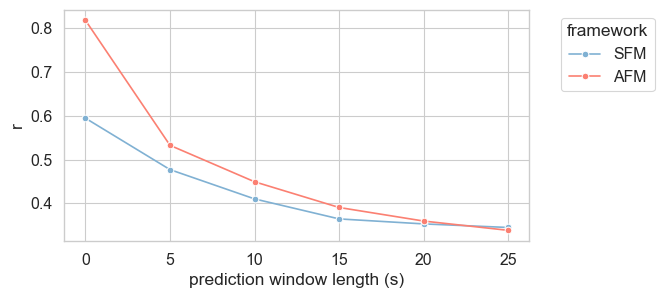

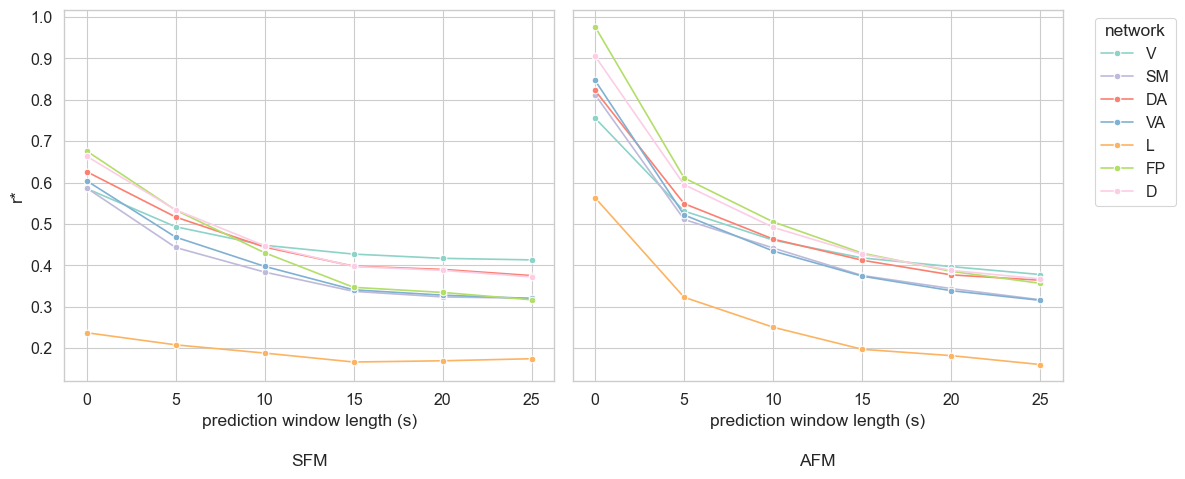

In [14]:
plot_temporal_ablation(root_data_dir, subjects,network_names, area_ids, palette_networks, ablation_type = "prediction")

# Plot Network

[0.3407781  0.25516737 0.32126373 0.23849583 0.08451379 0.27685937
 0.2895931 ]
[0.31860593 0.19176172 0.29247954 0.2033522  0.07539573 0.2675017
 0.2710662 ]
[0.37472945 0.291679   0.33408684 0.26550817 0.14597788 0.29311955
 0.31253418]
[0.33544818 0.26827416 0.30935332 0.2356562  0.09424956 0.2597836
 0.26847997]


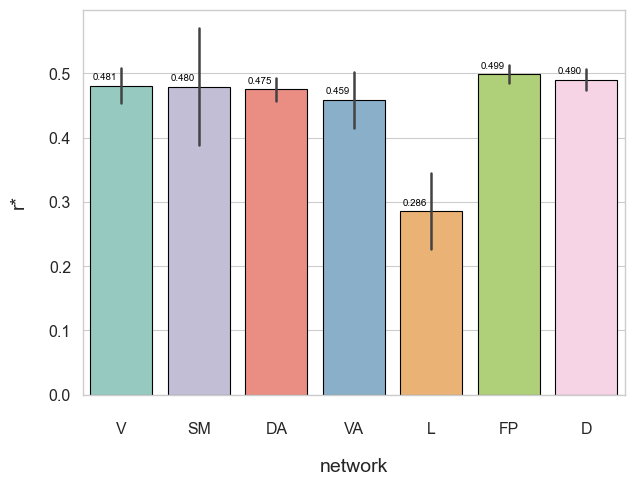

In [ ]:
reject_maps = []
obs_maps = {}
framework = "afm"
framework2 = "afm"
subjects = [1,2,3,5]

#load data
for subject in subjects:
    data_loaded = np.load(fr"{res_dir}/{framework}tochance.npz")[f"{subject}_areas_vs_chance"]
    obs_map = data_loaded[0]
    p_map = data_loaded[1]
    reject, p_corr, _, _ = multipletests(p_map, alpha=0.05, method="bonferroni")
    reject_maps.append(reject)
    obs_maps[subject] = obs_map

# get noise ceilings
noise_ceilings = get_noise_ceiling(root_data_dir, subjects, "per_area_per_subjects", area_ids)
noise_ceilings.append(get_noise_ceiling(root_data_dir,subjects, "per_area_across_subjects", area_ids))

# noise ceiling asjusted results
rows = []
for sub_id, (subj, values) in enumerate(obs_maps.items()):
    for area_idx, val in enumerate(values):

        rows.append({
            "Framework": "AFM",
            "Subject": subj,
            "Brain Network": network_names[area_idx] if network_names else area_idx,
            "Value": float(val) / noise_ceilings[sub_id][area_idx]
        })
df = pd.DataFrame(rows)

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=df,
    x="Brain Network",
    y="Value",
    errorbar="sd",  
    palette=palette_networks,
    edgecolor='black',
)
plt.xlabel("network",  labelpad=15, fontsize = 14)
plt.ylabel("r*",  labelpad=15, fontsize = 14)

add_values_above_bars(ax, 0.21, 0.005)
        
plt.show()

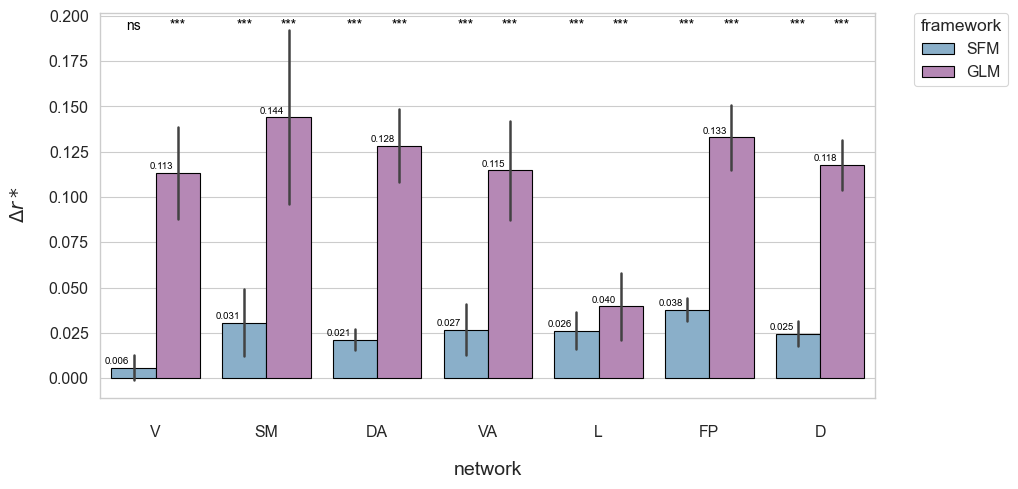

In [25]:
palette =  sns.color_palette("Set3")[4:5] + sns.color_palette("Set3")[9:10]  #[::-1] 

reject_maps = []
obs_maps = {}
reject_maps2 = []
obs_maps2 = {}
subjects = ["mean", 1,2,3,5]

framework1 = "afm"
modeltype1 = "gru"
hyper1 = "optimized"
framework2 = "sfm"
modeltype2 = "gru"
hyper2 = "optimized"
framework3 = "regression"
modeltype3 = "None"
hyper3 = "default"

for subject in subjects:
    
    data_loaded = np.load(fr"{res_dir}/{framework2}to{framework1}.npz")[f"{subject}_{framework2}_{modeltype2}_{hyper2}__vs__{framework1}_{modeltype1}_{hyper1}_areas"]
    obs_map = data_loaded[0]
    p_map = data_loaded[1]
    reject, p_corr, _, _ = multipletests(p_map, alpha=0.05, method="bonferroni")
    reject_maps.append(reject)
    obs_maps[subject] = obs_map

    data_loaded = np.load(fr"{res_dir}/{framework3}to{framework1}.npz")[f"{subject}_{framework3}_{modeltype3}_{hyper3}__vs__{framework1}_{modeltype1}_{hyper1}_areas"]
    obs_map = data_loaded[0]
    p_map2 = data_loaded[1]
    reject2, p_corr2, _, _ = multipletests(p_map2, alpha=0.05, method="bonferroni")
    reject_maps2.append(reject2)
    obs_maps2[subject] = obs_map


rows = []
for ((subj, values), (subj2, values2)) in zip(obs_maps.items(), obs_maps2.items()):
    if subj == "mean":
        continue
    for area_idx, (val, val2) in enumerate(zip(values, values2)):
        rows.append({
            "Framework": "SFM",
            "Subject": f"S{subj}",
            "Brain Network": network_names[area_idx] if network_names else area_idx,
            "Correlation": -float(val)
        })
        rows.append({
            "Framework": "GLM",
            "Subject": f"S{subj2}",
            "Brain Network": network_names[area_idx] if network_names else area_idx,
            "Correlation": -float(val2)
        })
    

df = pd.DataFrame(rows)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df,
    x="Brain Network",
    y="Correlation",
    errorbar="sd",   
    hue= "Framework",
    palette=palette,
    edgecolor='black',
)
plt.ylabel(r"$\Delta r*$",  labelpad=15, fontsize = 14)
plt.xlabel("network",  labelpad=15, fontsize = 14)
# plt.xticks(rotation=45)
add_values_above_bars(ax, 0.15, 0.003)

# add significance stars
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height != 0:

        ax.annotate(f'***' if i != 0 else "ns",
                    (p.get_x() + p.get_width() / 2., 0.187),
                    ha='center', va='bottom', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

plt.legend(
    title='framework',
    bbox_to_anchor=(1.05, 1),  
    loc='upper left',
    borderaxespad=0.
)
plt.show()

#### for CRPS

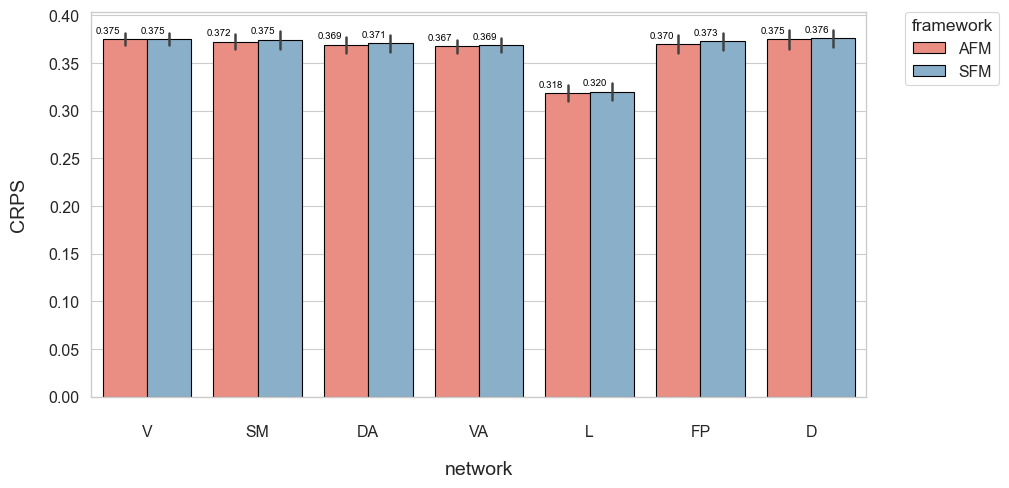

In [ ]:
subjects = [ 1,2,3,5]
rows = []

crps_per_subject = []
for framework in ["afm", "sfm"]:
    crps_dir = f"{res_dir}/crps_outputs_{framework}"
    for subject in subjects:
        values = np.load(f'{crps_dir}/{subject}.npy')#get_Y(res_dir, subjects, framework, modeltype, "testset", hyper)
        values = reduce_parcel_vector_to_areas(values, area_ids)
        for area_idx, val in enumerate(values):
            rows.append({
                    "Framework": "AFM" if framework == "afm" else "SFM",
                    "Subject": subject,
                    "Brain Network": network_names[area_idx] if network_names else area_idx,
                    "Value": float(val)
                })


df = pd.DataFrame(rows)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df,
    x="Brain Network",
    y="Value",
    errorbar="sd",   
    hue= "Framework",
    palette=sns.color_palette("Set3")[3:5],
    edgecolor='black',
)
plt.ylabel(r"CRPS",  labelpad=15, fontsize = 14)
plt.xlabel("network",  labelpad=15, fontsize = 14)
# plt.xticks(rotation=45)
add_values_above_bars(ax, 0.15, 0.003)

plt.legend(
    title='framework',
    bbox_to_anchor=(1.05, 1),  
    loc='upper left',
    borderaxespad=0.
)
plt.show()

# Plot time series

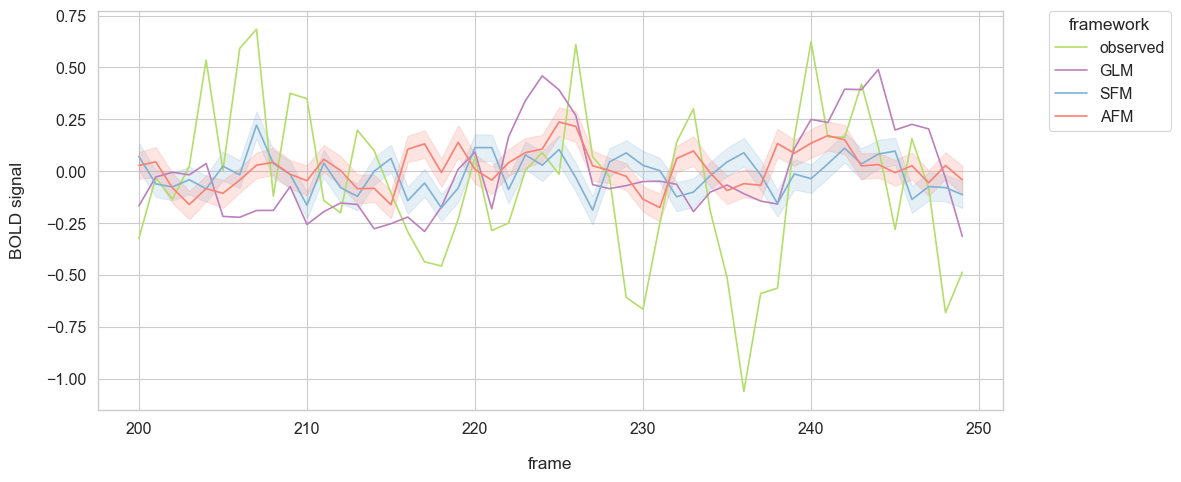

In [ ]:
start, stop = 200, 250
parcel = 7 # 2, 20
epi = "s06e06a"

palette =  sns.color_palette("Set3")[6:7] + sns.color_palette("Set3")[9:10] + sns.color_palette("Set3")[3:5][::-1] 

plot_time_series_comparison(res_dir, root_data_dir, start, stop, parcel, epi, palette, 1)

# Loss curves

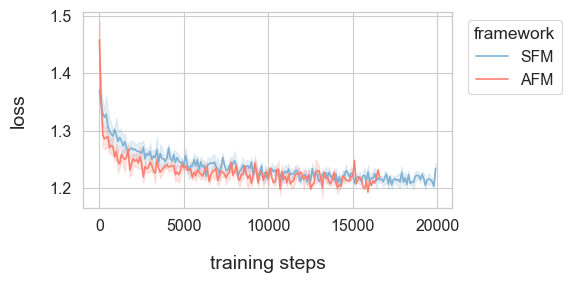

In [21]:
# sns.set_theme(style="white")
frameworks = ["sfm", "afm"]
modeltypes = ["gru", "gru", "gru"]
hypers     = ["optimized", "optimized", "optimized"]

EPOCH_STEP = 100 
subjects = [1,2,3,5]

all_data = []
for fw, mt, hp in zip(frameworks, modeltypes, hypers):

    for sub in subjects:
        path = os.path.join(res_dir, f"outputs_{fw}_{mt}_{hp}_testset_individual", f"s{sub}", "losses.pkl")

        with open(path, "rb") as f:
            losses = pickle.load(f)

        losses = np.asarray(losses, dtype=float).ravel()
        epochs = np.arange(1, len(losses) * EPOCH_STEP + 1, EPOCH_STEP)
        if fw == "sfm":
            fw_name = "SFM"
        elif fw == "afm":
            fw_name = "AFM"
        elif fw == "latentsde":
            fw_name = "LSNDEFM" 
        df_temp = pd.DataFrame({
            "Framework": fw_name,
            "Subject": f"sub-{sub:02d}",
            "Epoch": epochs,
            "Loss": losses,
        })
        all_data.append(df_temp)

df = pd.concat(all_data, ignore_index=True)

plt.figure(figsize=(6, 3))
sns.lineplot(
    data=df,
    x="Epoch",
    y="Loss",
    hue="Framework",
    errorbar="sd",        
    estimator="mean",     
    palette= palette2[::-1]
)

plt.xlabel("training steps",  labelpad=15, fontsize = 14)
plt.ylabel("loss",  labelpad=15, fontsize = 14)
plt.legend(title="framework", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()